# Pipeline B: Gating Analysis & Retrospective Simulation

**Purpose:** Analyze margin / BM25 distributions, validate gating feasibility, and run retrospective simulation (6 strategies x 6 budgets x 2 datasets).

**Phases:**
1. **Phase 1** — Margin & BM25 distribution analysis
2. **Phase 2** — Retrospective simulation (72 evaluation points per dataset)
3. **Phase 4** — Paper figures (Pareto curves, heatmap, alpha sensitivity)

**Data Sources:**
- BGL: `results/explanations_BGL_20260213_160034.normalized.jsonl` (6,290 sessions)
- HDFS: `results_HDFS/explanations_HDFS_20260215_220648.normalized.jsonl` (2,527 sessions)
- Evidence stores: `results/evidence_store_BGL.json`, `results_HDFS/evidence_store_HDFS.json`

## 1. Imports & Configuration

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Project root
PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

# Plot style — grayscale, 600 dpi
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'savefig.dpi': 600,
    'axes.prop_cycle': plt.cycler('color', [
        '0.0', '0.3', '0.5', '0.65', '0.8', '0.9'  # black → light gray
    ]),
})

Project root: /home/dave/agentic-log-explanations


In [2]:
# === Configuration ===

# Result files (normalized JSONL with screener + signature data)
BGL_JSONL = PROJECT_ROOT / "results" / "explanations_BGL_20260213_160034.normalized.jsonl"
HDFS_JSONL = PROJECT_ROOT / "results_HDFS" / "explanations_HDFS_20260215_220648.normalized.jsonl"

# Evidence stores (for BM25 reconstruction)
BGL_EVIDENCE = PROJECT_ROOT / "results" / "evidence_store_BGL.json"
HDFS_EVIDENCE = PROJECT_ROOT / "results_HDFS" / "evidence_store_HDFS.json"

# Budget levels for simulation
BUDGET_LEVELS = [0.10, 0.20, 0.30, 0.50, 0.75, 1.00]

# Alpha levels for sensitivity analysis
ALPHA_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Random seeds for random baseline
RANDOM_SEEDS = list(range(10))

print(f"BGL JSONL exists: {BGL_JSONL.exists()}")
print(f"HDFS JSONL exists: {HDFS_JSONL.exists()}")
print(f"BGL evidence exists: {BGL_EVIDENCE.exists()}")
print(f"HDFS evidence exists: {HDFS_EVIDENCE.exists()}")

BGL JSONL exists: True
HDFS JSONL exists: True
BGL evidence exists: True
HDFS evidence exists: True


## 2. Load Normalized JSONL Data

In [3]:
def load_normalized_jsonl(path: Path) -> pd.DataFrame:
    """Load normalized JSONL into a DataFrame with key fields."""
    records = []
    with open(path, 'r') as f:
        for line in f:
            d = json.loads(line)
            # Skip failed records (no explanation)
            if d.get('explanation') is None:
                continue
            records.append({
                'session_id': d['session_id'],
                'label': d['label'],
                'margin': d['screener']['margin'],
                'anomaly_prob': d['screener']['prob'][1],
                'confidence': d['screener']['confidence'],
                'normalized_signature': d.get('normalized_signature', d['explanation'].get('signature', {}).get('name', 'UNKNOWN')),
                'total_tokens': d['metrics']['total_tokens'],
                'latency_ms': d['metrics']['latency_ms'],
                'verification_passed': d.get('verification_passed', True),
                'num_claims': len(d['explanation'].get('claims', [])),
                'evidence_ids': d.get('evidence_ids', []),
            })
    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} records from {path.name}")
    print(f"  Unique normalized signatures: {df['normalized_signature'].nunique()}")
    print(f"  Verification pass rate: {df['verification_passed'].mean():.4f}")
    return df

df_bgl = load_normalized_jsonl(BGL_JSONL)
df_hdfs = load_normalized_jsonl(HDFS_JSONL)

Loaded 6290 records from explanations_BGL_20260213_160034.normalized.jsonl
  Unique normalized signatures: 56
  Verification pass rate: 0.9997
Loaded 2527 records from explanations_HDFS_20260215_220648.normalized.jsonl
  Unique normalized signatures: 13
  Verification pass rate: 1.0000


## 3. Phase 1 — Margin Distribution Analysis

In [4]:
def margin_statistics(df: pd.DataFrame, name: str) -> dict:
    """Compute and print margin statistics."""
    m = df['margin']
    stats = {
        'mean': m.mean(), 'std': m.std(),
        'min': m.min(), 'max': m.max(), 'median': m.median(),
        'p5': m.quantile(0.05), 'p25': m.quantile(0.25),
        'p75': m.quantile(0.75), 'p95': m.quantile(0.95),
        'below_0.9': (m < 0.9).sum(),
        'below_0.99': (m < 0.99).sum(),
        'below_0.999': (m < 0.999).sum(),
    }
    print(f"\n{'='*50}")
    print(f"Margin Statistics — {name} (N={len(df)})")
    print(f"{'='*50}")
    for k, v in stats.items():
        print(f"  {k:>15}: {v:.6f}" if isinstance(v, float) else f"  {k:>15}: {v}")
    return stats

bgl_margin_stats = margin_statistics(df_bgl, "BGL")
hdfs_margin_stats = margin_statistics(df_hdfs, "HDFS")


Margin Statistics — BGL (N=6290)
             mean: 0.995200
              std: 0.051535
              min: 0.008237
              max: 1.000000
           median: 1.000000
               p5: 1.000000
              p25: 1.000000
              p75: 1.000000
              p95: 1.000000
        below_0.9: 73
       below_0.99: 105
      below_0.999: 145

Margin Statistics — HDFS (N=2527)
             mean: 0.999611
              std: 0.017057
              min: 0.145755
              max: 0.999999
           median: 0.999998
               p5: 0.999998
              p25: 0.999998
              p75: 0.999998
              p95: 0.999998
        below_0.9: 1
       below_0.99: 4
      below_0.999: 6


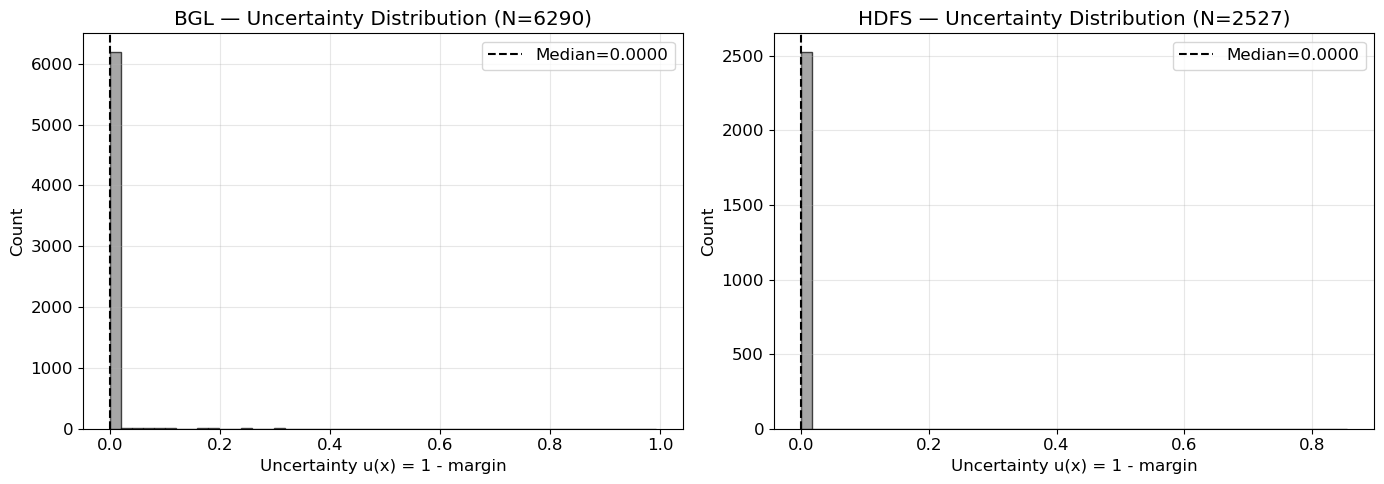

Saved: results/gating_uncertainty_distribution.png


In [5]:
# Margin distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in [(axes[0], df_bgl, 'BGL'), (axes[1], df_hdfs, 'HDFS')]:
    u = 1 - df['margin']
    ax.hist(u, bins=50, edgecolor='black', alpha=0.7, color='0.5')
    ax.set_xlabel('Uncertainty u(x) = 1 - margin')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Uncertainty Distribution (N={len(df)})')
    ax.axvline(u.median(), color='black', linestyle='--', label=f'Median={u.median():.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'gating_uncertainty_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: results/gating_uncertainty_distribution.png")

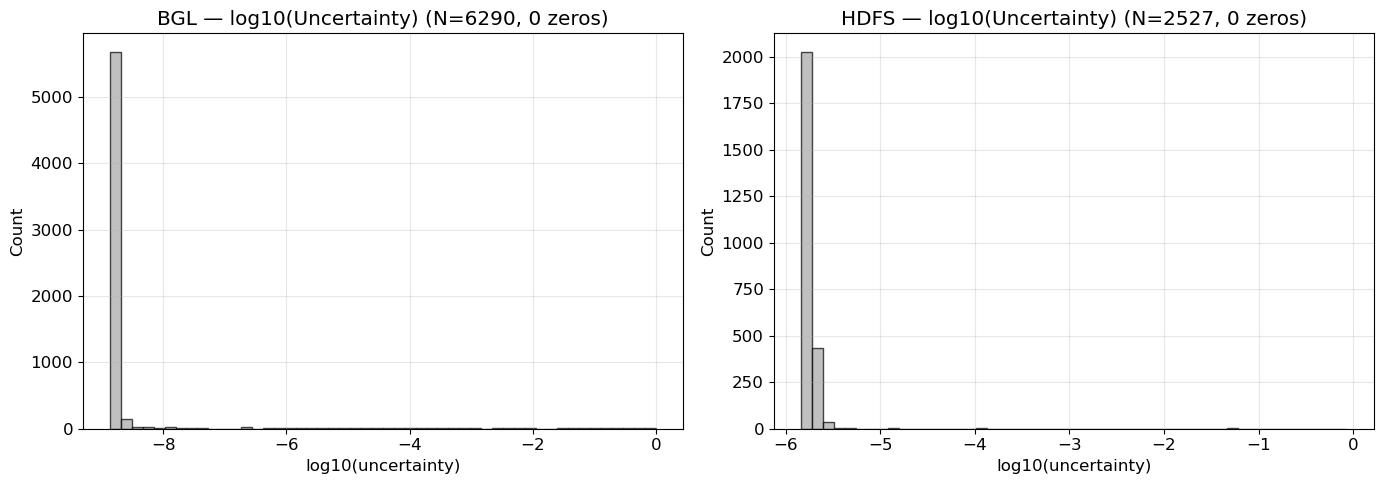

Saved: results/gating_uncertainty_log_distribution.png


In [6]:
# Detailed margin histogram with log scale (to see tail behavior)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in [(axes[0], df_bgl, 'BGL'), (axes[1], df_hdfs, 'HDFS')]:
    u = 1 - df['margin']
    u_nonzero = u[u > 0]
    ax.hist(np.log10(u_nonzero), bins=50, edgecolor='black', alpha=0.7, color='0.65')
    ax.set_xlabel('log10(uncertainty)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — log10(Uncertainty) (N={len(u_nonzero)}, {len(u)-len(u_nonzero)} zeros)')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'gating_uncertainty_log_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: results/gating_uncertainty_log_distribution.png")

## 4. BM25 Score Reconstruction

The JSONL files do not contain BM25 scores; we need to rebuild the BM25 index and query each anomaly session.

**Note:** This step loads the evidence store (BGL ~500K docs, HDFS ~400K docs), which requires significant memory.

In [7]:
from src.evidence_store import EvidenceStore
from src.retriever import BM25Retriever
from src.data_loader import BGLDataLoader, HDFSDataLoader

In [8]:
def compute_bm25_scores(
    evidence_path: Path,
    data_loader,
    session_ids: List[str],
    dataset: str,
    cache_path: Optional[Path] = None,
    checkpoint_interval: int = 100,
) -> Dict[str, float]:
    """
    Rebuild BM25 index and compute max BM25 score for each anomaly session.
    
    Supports:
    - Disk caching: if cache_path exists, load from it directly (skip computation).
    - Incremental checkpointing: saves progress every `checkpoint_interval` sessions
      so computation can resume after a crash.

    Args:
        evidence_path: Path to evidence store JSON
        data_loader: BGLDataLoader or HDFSDataLoader (already loaded)
        session_ids: List of session IDs to compute BM25 for
        dataset: 'BGL' or 'HDFS'
        cache_path: Path to save/load final results (.json)
        checkpoint_interval: Save checkpoint every N sessions

    Returns:
        Dict mapping session_id -> bm25_max score
    """
    # --- Check for completed cache ---
    if cache_path and cache_path.exists():
        with open(cache_path, 'r') as f:
            cached = json.load(f)
        print(f"  [OK] Loaded {len(cached)} cached BM25 scores from {cache_path.name}")
        # Verify all requested session_ids are present
        missing_ids = set(session_ids) - set(cached.keys())
        if not missing_ids:
            return cached
        print(f"  [WARN] Cache missing {len(missing_ids)} sessions -- resuming computation")
    else:
        cached = {}

    # --- Check for partial checkpoint ---
    checkpoint_path = cache_path.with_suffix('.checkpoint.json') if cache_path else None
    bm25_scores = {}
    if checkpoint_path and checkpoint_path.exists():
        with open(checkpoint_path, 'r') as f:
            bm25_scores = json.load(f)
        print(f"  [RESUME] From checkpoint: {len(bm25_scores)} sessions already done")
    bm25_scores.update(cached)  # merge any cached results

    # --- Determine remaining work ---
    remaining_ids = [sid for sid in session_ids if sid not in bm25_scores]
    if not remaining_ids:
        print(f"  [OK] All {len(session_ids)} sessions already computed")
        # Save final cache
        if cache_path:
            with open(cache_path, 'w') as f:
                json.dump(bm25_scores, f)
        return bm25_scores

    print(f"  Computing BM25 for {len(remaining_ids)} remaining sessions "
          f"({len(bm25_scores)} already done, {len(session_ids)} total)")

    # --- Build BM25 index ---
    es = EvidenceStore(dataset=dataset)
    es.load(str(evidence_path))

    retriever = BM25Retriever(evidence_store=es)
    retriever.build_index()

    # --- Build session lookup ---
    all_sessions = data_loader.get_sessions()
    session_map = {s.session_id: s for s in all_sessions}
    print(f"  Session map size: {len(session_map)}")

    # --- Compute BM25 scores with checkpointing ---
    missing = 0
    newly_computed = 0

    for i, sid in enumerate(tqdm(remaining_ids, desc=f"BM25 ({dataset})")):
        if sid not in session_map:
            missing += 1
            bm25_scores[sid] = 0.0
        else:
            session = session_map[sid]
            hits = retriever.retrieve_for_session(session, top_k=5, exclude_self=True)
            bm25_scores[sid] = max(h.score for h in hits) if hits else 0.0

        newly_computed += 1

        # Incremental checkpoint
        if checkpoint_path and (newly_computed % checkpoint_interval == 0):
            with open(checkpoint_path, 'w') as f:
                json.dump(bm25_scores, f)
            # tqdm will show progress; no extra print needed

    if missing > 0:
        print(f"  Warning: {missing} sessions not found in data loader")

    # --- Save final cache & clean up checkpoint ---
    if cache_path:
        with open(cache_path, 'w') as f:
            json.dump(bm25_scores, f)
        print(f"  [OK] Saved {len(bm25_scores)} BM25 scores to {cache_path.name}")
        if checkpoint_path and checkpoint_path.exists():
            checkpoint_path.unlink()
            print(f"  [OK] Cleaned up checkpoint file")

    return bm25_scores

In [9]:
# === BGL BM25 Scores ===
BGL_BM25_CACHE = PROJECT_ROOT / "results" / "bm25_scores_BGL.json"

if BGL_BM25_CACHE.exists():
    print(f"Loading cached BGL BM25 scores from {BGL_BM25_CACHE.name}...")
    with open(BGL_BM25_CACHE, 'r') as f:
        bgl_bm25 = json.load(f)
    print(f"  [OK] Loaded {len(bgl_bm25)} scores")
else:
    print("Loading BGL data...")
    bgl_loader = BGLDataLoader(
        log_file=str(PROJECT_ROOT / "logs" / "BGL.log"),
        windows_size=10,
        step_size=10,
        train_ratio=0.7
    )
    bgl_loader.load()

    bgl_bm25 = compute_bm25_scores(
        evidence_path=BGL_EVIDENCE,
        data_loader=bgl_loader,
        session_ids=df_bgl['session_id'].tolist(),
        dataset='BGL',
        cache_path=BGL_BM25_CACHE,
        checkpoint_interval=200,
    )

# Add to DataFrame
df_bgl['bm25_max'] = df_bgl['session_id'].map(bgl_bm25)
print(f"\nBGL BM25 scores: mean={df_bgl['bm25_max'].mean():.2f}, std={df_bgl['bm25_max'].std():.2f}")
print(f"  min={df_bgl['bm25_max'].min():.2f}, max={df_bgl['bm25_max'].max():.2f}")

Loading BGL data...
Loading BGL logs from: /home/dave/agentic-log-explanations/logs/BGL.log


Reading BGL logs: 4747963it [00:01, 3382488.36it/s]


Loaded 4747963 log lines


Creating sessions: 100%|██████████| 474796/474796 [00:02<00:00, 199344.34it/s]


  Computing BM25 for 6290 remaining sessions (0 already done, 6290 total)
Evidence store loaded from /home/dave/agentic-log-explanations/results/evidence_store_BGL.json (332356 documents)
Building BM25 index...
BM25 index built with 332356 documents
  Session map size: 474796


BM25 (BGL): 100%|██████████| 6290/6290 [11:23:27<00:00,  6.52s/it]  


  [OK] Saved 6290 BM25 scores to bm25_scores_BGL.json
  [OK] Cleaned up checkpoint file

BGL BM25 scores: mean=964.09, std=445.20
  min=476.30, max=3284.66


In [10]:
# === HDFS BM25 Scores ===
HDFS_BM25_CACHE = PROJECT_ROOT / "results_HDFS" / "bm25_scores_HDFS.json"

if HDFS_BM25_CACHE.exists():
    print(f"Loading cached HDFS BM25 scores from {HDFS_BM25_CACHE.name}...")
    with open(HDFS_BM25_CACHE, 'r') as f:
        hdfs_bm25 = json.load(f)
    print(f"  [OK] Loaded {len(hdfs_bm25)} scores")
else:
    print("Loading HDFS data...")
    hdfs_loader = HDFSDataLoader(
        log_file=str(PROJECT_ROOT / "logs" / "HDFS.log"),
        label_file=str(PROJECT_ROOT / "logs" / "anomaly_label_HDFS.csv"),
        train_ratio=0.7
    )
    hdfs_loader.load()

    hdfs_bm25 = compute_bm25_scores(
        evidence_path=HDFS_EVIDENCE,
        data_loader=hdfs_loader,
        session_ids=df_hdfs['session_id'].tolist(),
        dataset='HDFS',
        cache_path=HDFS_BM25_CACHE,
        checkpoint_interval=100,
    )

# Add to DataFrame
df_hdfs['bm25_max'] = df_hdfs['session_id'].map(hdfs_bm25)
print(f"\nHDFS BM25 scores: mean={df_hdfs['bm25_max'].mean():.2f}, std={df_hdfs['bm25_max'].std():.2f}")
print(f"  min={df_hdfs['bm25_max'].min():.2f}, max={df_hdfs['bm25_max'].max():.2f}")

Loading HDFS data...
Loading HDFS logs from: /home/dave/agentic-log-explanations/logs/HDFS.log
Loading labels from: /home/dave/agentic-log-explanations/logs/anomaly_label_HDFS.csv


Reading HDFS logs: 11175629it [00:27, 402715.97it/s] 


Found 575061 unique blocks
  Computing BM25 for 2527 remaining sessions (0 already done, 2527 total)
Evidence store loaded from /home/dave/agentic-log-explanations/results_HDFS/evidence_store_HDFS.json (402542 documents)
Building BM25 index...
BM25 index built with 402542 documents
  Session map size: 575061


BM25 (HDFS): 100%|██████████| 2527/2527 [10:58:07<00:00, 15.63s/it]  


  [OK] Saved 2527 BM25 scores to bm25_scores_HDFS.json
  [OK] Cleaned up checkpoint file

HDFS BM25 scores: mean=710.23, std=487.35
  min=66.70, max=2581.31


## 5. Phase 1 — BM25 / Novelty Distribution & Gating Features

In [11]:
def compute_gating_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute gating features u(x) and n(x) for each session.

    u(x) = 1 - margin              (uncertainty)
    n(x) = 1 - bm25_max / max(bm25_max)  (retrieval novelty)
    """
    df = df.copy()

    # Uncertainty
    df['u'] = 1.0 - df['margin']

    # Retrieval novelty (normalized)
    bm25_global_max = df['bm25_max'].max()
    if bm25_global_max > 0:
        df['n'] = 1.0 - (df['bm25_max'] / bm25_global_max)
    else:
        df['n'] = 1.0

    print(f"u(x): mean={df['u'].mean():.6f}, std={df['u'].std():.6f}, min={df['u'].min():.6f}, max={df['u'].max():.6f}")
    print(f"n(x): mean={df['n'].mean():.6f}, std={df['n'].std():.6f}, min={df['n'].min():.6f}, max={df['n'].max():.6f}")
    print(f"Correlation(u, n): {df['u'].corr(df['n']):.4f}")

    return df

print("=== BGL ===")
df_bgl = compute_gating_features(df_bgl)
print("\n=== HDFS ===")
df_hdfs = compute_gating_features(df_hdfs)

=== BGL ===
u(x): mean=0.004800, std=0.051535, min=0.000000, max=0.991763
n(x): mean=0.706487, std=0.135539, min=0.000000, max=0.854994
Correlation(u, n): -0.1177

=== HDFS ===
u(x): mean=0.000389, std=0.017057, min=0.000001, max=0.854245
n(x): mean=0.724855, std=0.188798, min=0.000000, max=0.974159
Correlation(u, n): -0.0117


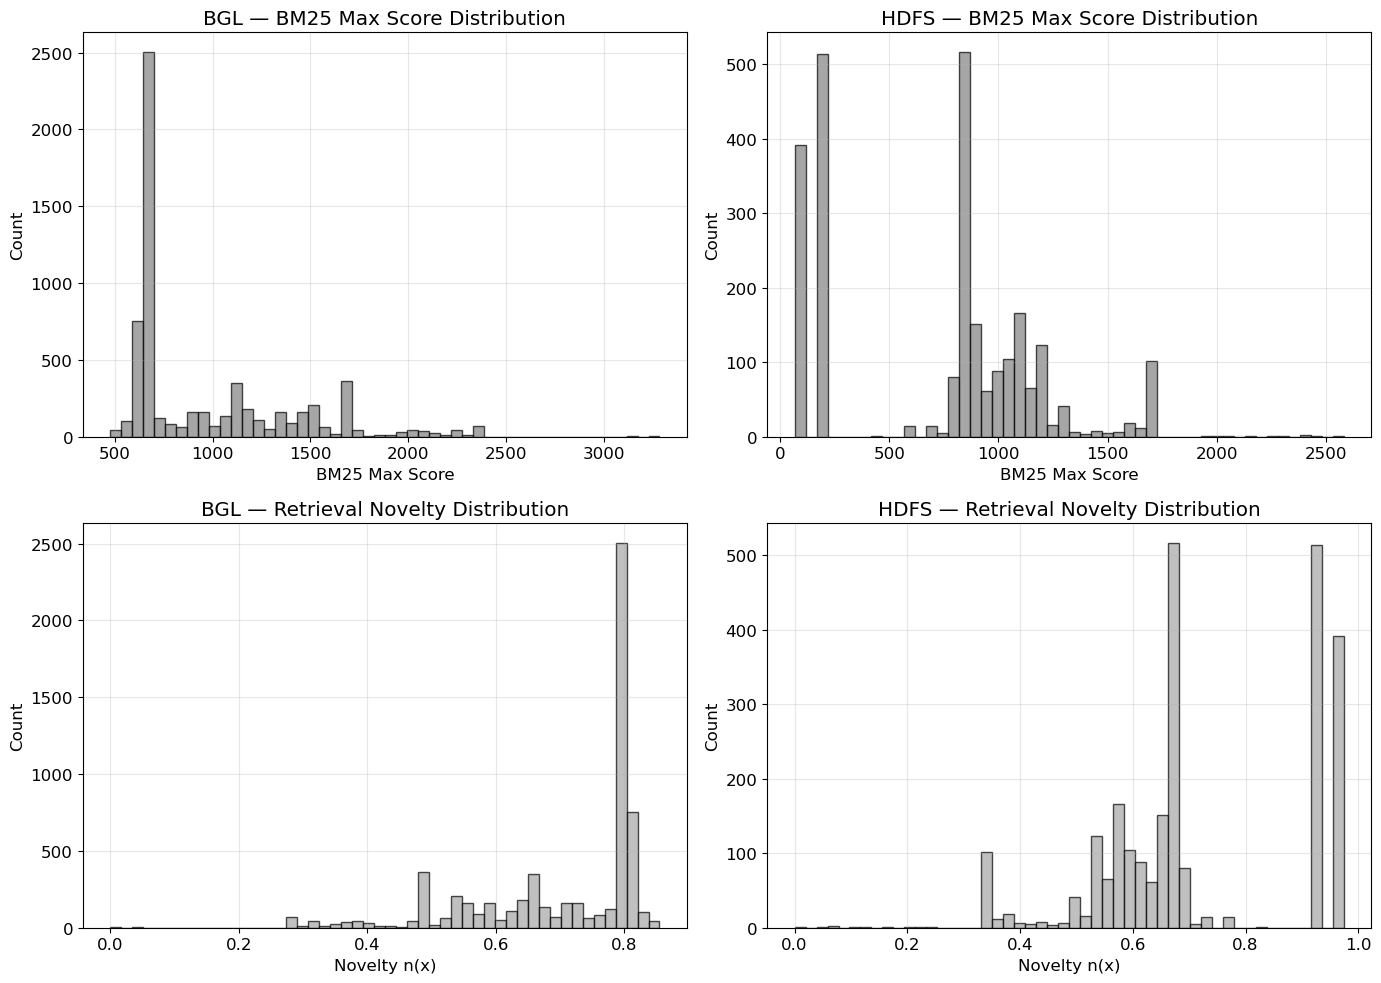

Saved: results/gating_bm25_novelty_distribution.png


In [12]:
# BM25 and novelty distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (df, name) in enumerate([(df_bgl, 'BGL'), (df_hdfs, 'HDFS')]):
    axes[0, col].hist(df['bm25_max'], bins=50, edgecolor='black', alpha=0.7, color='0.5')
    axes[0, col].set_xlabel('BM25 Max Score')
    axes[0, col].set_ylabel('Count')
    axes[0, col].set_title(f'{name} — BM25 Max Score Distribution')

    axes[1, col].hist(df['n'], bins=50, edgecolor='black', alpha=0.7, color='0.65')
    axes[1, col].set_xlabel('Novelty n(x)')
    axes[1, col].set_ylabel('Count')
    axes[1, col].set_title(f'{name} — Retrieval Novelty Distribution')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'gating_bm25_novelty_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: results/gating_bm25_novelty_distribution.png")

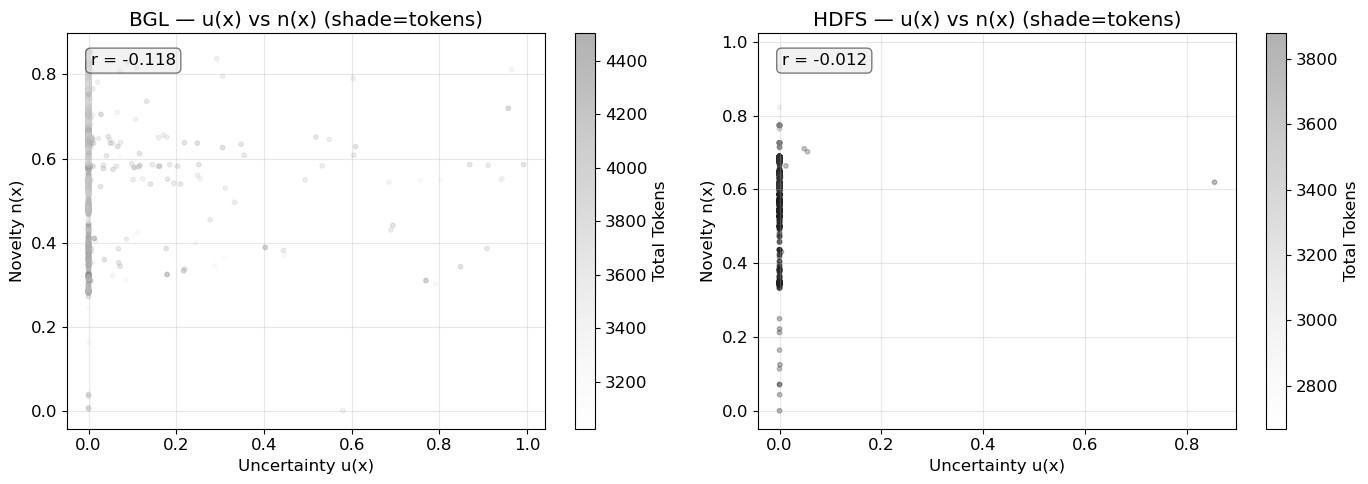

Saved: results/gating_u_vs_n_scatter.png


In [13]:
# u(x) vs n(x) scatter — check if they provide complementary information
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in [(axes[0], df_bgl, 'BGL'), (axes[1], df_hdfs, 'HDFS')]:
    scatter = ax.scatter(df['u'], df['n'], alpha=0.3, s=10,
                         c=df['total_tokens'], cmap='Greys')
    ax.set_xlabel('Uncertainty u(x)')
    ax.set_ylabel('Novelty n(x)')
    ax.set_title(f'{name} — u(x) vs n(x) (shade=tokens)')
    plt.colorbar(scatter, ax=ax, label='Total Tokens')

    corr = df['u'].corr(df['n'])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='0.9', alpha=0.5))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'gating_u_vs_n_scatter.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: results/gating_u_vs_n_scatter.png")

## 6. Phase 1 — Signature Distribution (Long-tail Analysis)

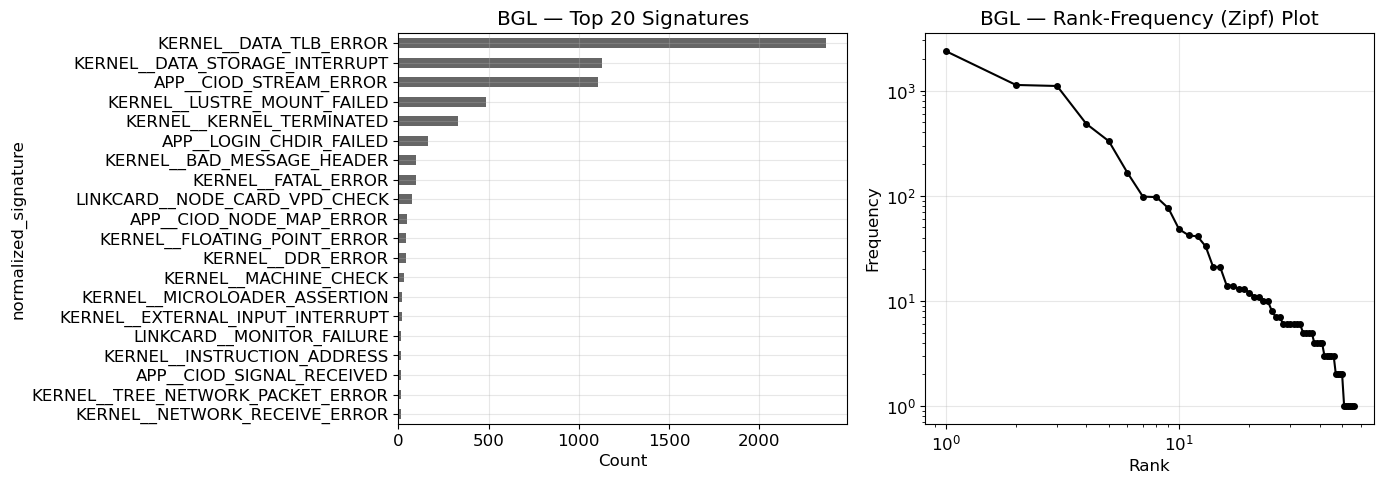


BGL Signature Statistics:
  Total sessions: 6290
  Unique signatures: 56
  Top 3 coverage: 73.2%
  Top 5 coverage: 86.1%
  Singletons (count=1): 6
  Tail (count<=5): 23


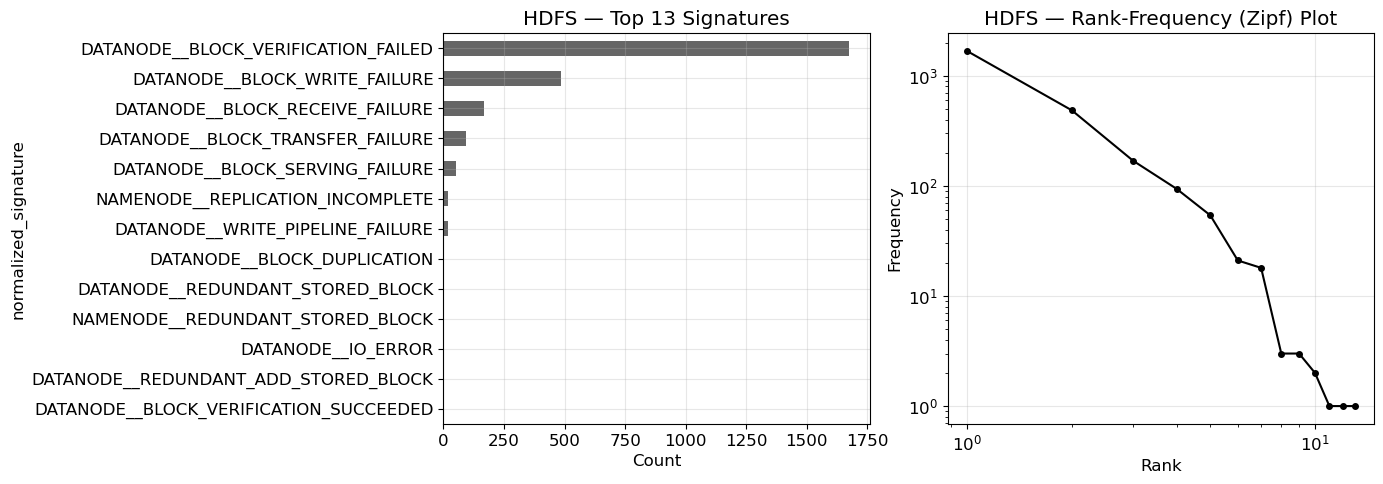


HDFS Signature Statistics:
  Total sessions: 2527
  Unique signatures: 13
  Top 3 coverage: 92.2%
  Top 5 coverage: 98.0%
  Singletons (count=1): 3
  Tail (count<=5): 6


In [14]:
def plot_signature_distribution(df: pd.DataFrame, name: str, top_n: int = 20):
    """Plot signature frequency distribution (Zipf-like)."""
    sig_counts = df['normalized_signature'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    display_n = min(top_n, len(sig_counts))
    sig_counts.head(display_n).plot(kind='barh', ax=axes[0], color='0.4')
    axes[0].set_xlabel('Count')
    axes[0].set_title(f'{name} — Top {display_n} Signatures')
    axes[0].invert_yaxis()

    ranks = np.arange(1, len(sig_counts) + 1)
    axes[1].plot(ranks, sig_counts.values, 'o-', markersize=4, color='black')
    axes[1].set_xlabel('Rank')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{name} — Rank-Frequency (Zipf) Plot')
    axes[1].set_yscale('log')
    axes[1].set_xscale('log')

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'results' / f'gating_signature_distribution_{name}.png', dpi=600, bbox_inches='tight')
    plt.show()

    total = len(df)
    unique = len(sig_counts)
    top3_cov = sig_counts.head(3).sum() / total
    top5_cov = sig_counts.head(5).sum() / total
    singletons = (sig_counts == 1).sum()
    tail_5 = (sig_counts <= 5).sum()

    print(f"\n{name} Signature Statistics:")
    print(f"  Total sessions: {total}")
    print(f"  Unique signatures: {unique}")
    print(f"  Top 3 coverage: {top3_cov:.1%}")
    print(f"  Top 5 coverage: {top5_cov:.1%}")
    print(f"  Singletons (count=1): {singletons}")
    print(f"  Tail (count<=5): {tail_5}")
    return sig_counts

bgl_sig_counts = plot_signature_distribution(df_bgl, 'BGL')
hdfs_sig_counts = plot_signature_distribution(df_hdfs, 'HDFS')

## 7. Phase 2 — Retrospective Simulation

### Gating Strategies

| Strategy | Selection Rule |
|---|---|
| **Random** | Uniform random K sessions (avg over 10 seeds) |
| **Uncertainty** | Top-K by u(x) = 1 - m(x) |
| **Novelty** | Top-K by n(x) = 1 - bm25_max(x) / max(bm25_max) |
| **Combined** | Top-K by s(x) = 0.5 u(x) + 0.5 n(x) |
| **Stratified** | K sessions sampled proportionally per signature |
| **Oracle** | Maximize unique signatures at budget K |

In [15]:
# === Gating Strategy Functions ===

def select_random(df: pd.DataFrame, k: int, seed: int = 42) -> pd.DataFrame:
    """Random selection baseline."""
    return df.sample(n=k, random_state=seed)

def select_by_score(df: pd.DataFrame, k: int, score_col: str) -> pd.DataFrame:
    """Select top-K by a score column (higher = selected)."""
    return df.nlargest(k, score_col)

def select_stratified(df: pd.DataFrame, k: int, seed: int = 42) -> pd.DataFrame:
    """Proportional sampling per normalized_signature."""
    rng = np.random.RandomState(seed)
    sig_counts = df['normalized_signature'].value_counts()
    total = len(df)

    selected_indices = []

    # Allocate proportionally, at least 1 per signature if budget allows
    allocations = {}
    for sig, count in sig_counts.items():
        alloc = max(1, round(k * count / total))
        allocations[sig] = min(alloc, count)

    # Adjust if over-allocated
    total_alloc = sum(allocations.values())
    if total_alloc > k:
        for sig in sorted(allocations, key=allocations.get, reverse=True):
            if total_alloc <= k:
                break
            reduce = min(allocations[sig] - 1, total_alloc - k)
            allocations[sig] -= reduce
            total_alloc -= reduce
    elif total_alloc < k:
        for sig in sorted(allocations, key=lambda s: sig_counts[s], reverse=True):
            if total_alloc >= k:
                break
            can_add = min(sig_counts[sig] - allocations[sig], k - total_alloc)
            allocations[sig] += can_add
            total_alloc += can_add

    # Sample from each signature group
    for sig, alloc in allocations.items():
        sig_df = df[df['normalized_signature'] == sig]
        sampled = sig_df.sample(n=min(alloc, len(sig_df)), random_state=rng)
        selected_indices.extend(sampled.index.tolist())

    return df.loc[selected_indices[:k]]

def select_oracle(df: pd.DataFrame, k: int) -> pd.DataFrame:
    """Oracle: maximize unique signatures at budget K.
    Greedy: pick 1 session per signature (rarest first), then fill remaining.
    """
    sig_counts = df['normalized_signature'].value_counts(ascending=True)
    selected_indices = []
    seen_sigs = set()

    for sig in sig_counts.index:
        if len(selected_indices) >= k:
            break
        sig_df = df[df['normalized_signature'] == sig]
        selected_indices.append(sig_df.index[0])
        seen_sigs.add(sig)

    if len(selected_indices) < k:
        remaining = df.drop(index=selected_indices)
        need = k - len(selected_indices)
        selected_indices.extend(remaining.index[:need].tolist())

    return df.loc[selected_indices[:k]]

print("Gating strategy functions defined.")

Gating strategy functions defined.


In [16]:
# === Evaluation Function ===

def evaluate_subset(subset: pd.DataFrame, full_df: pd.DataFrame) -> dict:
    """Evaluate a gated subset against the full set."""
    full_sigs = set(full_df['normalized_signature'].unique())
    subset_sigs = set(subset['normalized_signature'].unique())

    return {
        'n_selected': len(subset),
        'n_total': len(full_df),
        'budget_ratio': len(subset) / len(full_df),
        'unique_sigs': len(subset_sigs),
        'total_unique_sigs': len(full_sigs),
        'coverage': len(subset_sigs) / len(full_sigs) if full_sigs else 0,
        'missing_sigs': full_sigs - subset_sigs,
        'total_tokens': subset['total_tokens'].sum(),
        'total_tokens_full': full_df['total_tokens'].sum(),
        'token_savings': 1 - subset['total_tokens'].sum() / full_df['total_tokens'].sum(),
        'avg_tokens': subset['total_tokens'].mean(),
        'total_latency_ms': subset['latency_ms'].sum(),
        'vpr': subset['verification_passed'].mean() if len(subset) > 0 else 0,
        'avg_claims': subset['num_claims'].mean() if len(subset) > 0 else 0,
    }

print("Evaluation function defined.")

Evaluation function defined.


In [17]:
# === Run Full Simulation ===

def run_simulation(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Run all gating strategies at all budget levels."""
    df = df.copy()
    df['s_combined'] = 0.5 * df['u'] + 0.5 * df['n']

    results = []

    for B in BUDGET_LEVELS:
        K = max(1, int(np.floor(B * len(df))))

        # --- Uncertainty ---
        subset = select_by_score(df, K, 'u')
        ev = evaluate_subset(subset, df)
        ev.update({'strategy': 'Uncertainty', 'budget': B, 'dataset': dataset_name})
        results.append(ev)

        # --- Novelty ---
        subset = select_by_score(df, K, 'n')
        ev = evaluate_subset(subset, df)
        ev.update({'strategy': 'Novelty', 'budget': B, 'dataset': dataset_name})
        results.append(ev)

        # --- Combined ---
        subset = select_by_score(df, K, 's_combined')
        ev = evaluate_subset(subset, df)
        ev.update({'strategy': 'Combined', 'budget': B, 'dataset': dataset_name})
        results.append(ev)

        # --- Stratified ---
        subset = select_stratified(df, K)
        ev = evaluate_subset(subset, df)
        ev.update({'strategy': 'Stratified', 'budget': B, 'dataset': dataset_name})
        results.append(ev)

        # --- Oracle ---
        subset = select_oracle(df, K)
        ev = evaluate_subset(subset, df)
        ev.update({'strategy': 'Oracle', 'budget': B, 'dataset': dataset_name})
        results.append(ev)

        # --- Random (10 seeds) ---
        random_covs = []
        random_tokens = []
        for seed in RANDOM_SEEDS:
            subset = select_random(df, K, seed=seed)
            ev_r = evaluate_subset(subset, df)
            random_covs.append(ev_r['coverage'])
            random_tokens.append(ev_r['total_tokens'])

        ev_random = evaluate_subset(select_random(df, K, seed=42), df)
        ev_random.update({
            'strategy': 'Random',
            'budget': B,
            'dataset': dataset_name,
            'coverage': np.mean(random_covs),
            'coverage_std': np.std(random_covs),
            'coverage_min': np.min(random_covs),
            'coverage_max': np.max(random_covs),
            'total_tokens': np.mean(random_tokens),
        })
        results.append(ev_random)

    return pd.DataFrame(results)

print("Running BGL simulation...")
sim_bgl = run_simulation(df_bgl, 'BGL')
print(f"  Done: {len(sim_bgl)} evaluation points")

print("\nRunning HDFS simulation...")
sim_hdfs = run_simulation(df_hdfs, 'HDFS')
print(f"  Done: {len(sim_hdfs)} evaluation points")

sim_all = pd.concat([sim_bgl, sim_hdfs], ignore_index=True)
print(f"\nTotal evaluation points: {len(sim_all)}")

Running BGL simulation...
  Done: 36 evaluation points

Running HDFS simulation...
  Done: 36 evaluation points

Total evaluation points: 72


In [18]:
# === Display Results Table ===

display_cols = ['dataset', 'strategy', 'budget', 'n_selected', 'unique_sigs',
                'total_unique_sigs', 'coverage', 'token_savings', 'vpr']

print("\n" + "="*80)
print("BGL Results")
print("="*80)
bgl_table = sim_bgl[display_cols].copy()
bgl_table['coverage'] = bgl_table['coverage'].map('{:.1%}'.format)
bgl_table['token_savings'] = bgl_table['token_savings'].map('{:.1%}'.format)
bgl_table['vpr'] = bgl_table['vpr'].map('{:.2%}'.format)
print(bgl_table.to_string(index=False))

print("\n" + "="*80)
print("HDFS Results")
print("="*80)
hdfs_table = sim_hdfs[display_cols].copy()
hdfs_table['coverage'] = hdfs_table['coverage'].map('{:.1%}'.format)
hdfs_table['token_savings'] = hdfs_table['token_savings'].map('{:.1%}'.format)
hdfs_table['vpr'] = hdfs_table['vpr'].map('{:.2%}'.format)
print(hdfs_table.to_string(index=False))


BGL Results
dataset    strategy  budget  n_selected  unique_sigs  total_unique_sigs coverage token_savings     vpr
    BGL Uncertainty    0.10         629           42                 56    75.0%         89.7%  99.68%
    BGL     Novelty    0.10         629            8                 56    14.3%         90.1% 100.00%
    BGL    Combined    0.10         629           21                 56    37.5%         90.1% 100.00%
    BGL  Stratified    0.10         629           56                 56   100.0%         90.0% 100.00%
    BGL      Oracle    0.10         629           56                 56   100.0%         90.0% 100.00%
    BGL      Random    0.10         629           29                 56    54.6%         90.0%  99.84%
    BGL Uncertainty    0.20        1258           53                 56    94.6%         79.7%  99.84%
    BGL     Novelty    0.20        1258            8                 56    14.3%         80.2% 100.00%
    BGL    Combined    0.20        1258           21        

## 8. Phase 4 — Paper Figures

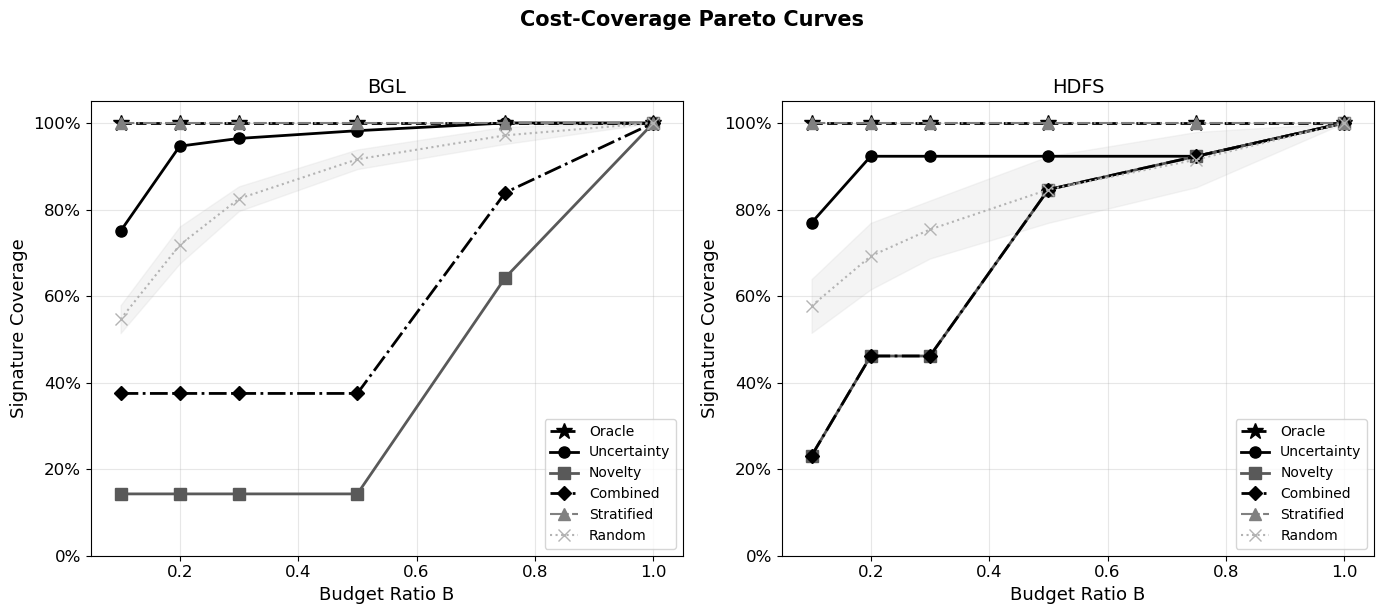

Saved: results/gating_pareto_curves.png


In [19]:
# === Fig 1: Cost-Coverage Pareto Curves ===

# Grayscale styles: distinct via linestyle + marker + gray level
STRATEGY_STYLES = {
    'Oracle':       {'color': '0.0',  'marker': '*', 'linestyle': '--',  'linewidth': 2,   'markersize': 12},
    'Uncertainty':  {'color': '0.0',  'marker': 'o', 'linestyle': '-',   'linewidth': 2,   'markersize': 8},
    'Novelty':      {'color': '0.35', 'marker': 's', 'linestyle': '-',   'linewidth': 2,   'markersize': 8},
    'Combined':     {'color': '0.0',  'marker': 'D', 'linestyle': '-.',  'linewidth': 2,   'markersize': 7},
    'Stratified':   {'color': '0.5',  'marker': '^', 'linestyle': '-.',  'linewidth': 1.5, 'markersize': 8},
    'Random':       {'color': '0.7',  'marker': 'x', 'linestyle': ':',   'linewidth': 1.5, 'markersize': 8},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, dataset_name in [(axes[0], 'BGL'), (axes[1], 'HDFS')]:
    sim_ds = sim_all[sim_all['dataset'] == dataset_name]

    for strategy, style in STRATEGY_STYLES.items():
        data = sim_ds[sim_ds['strategy'] == strategy].sort_values('budget')
        if data.empty:
            continue

        ax.plot(data['budget'], data['coverage'],
                label=strategy, **style)

        if strategy == 'Random' and 'coverage_std' in data.columns:
            ax.fill_between(
                data['budget'],
                data['coverage'] - data.get('coverage_std', 0),
                data['coverage'] + data.get('coverage_std', 0),
                alpha=0.2, color='0.8'
            )

    ax.set_xlabel('Budget Ratio B', fontsize=13)
    ax.set_ylabel('Signature Coverage', fontsize=13)
    ax.set_title(f'{dataset_name}', fontsize=14)
    ax.set_xlim(0.05, 1.05)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=10, loc='lower right')

fig.suptitle('Cost-Coverage Pareto Curves', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'gating_pareto_curves.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: results/gating_pareto_curves.png")

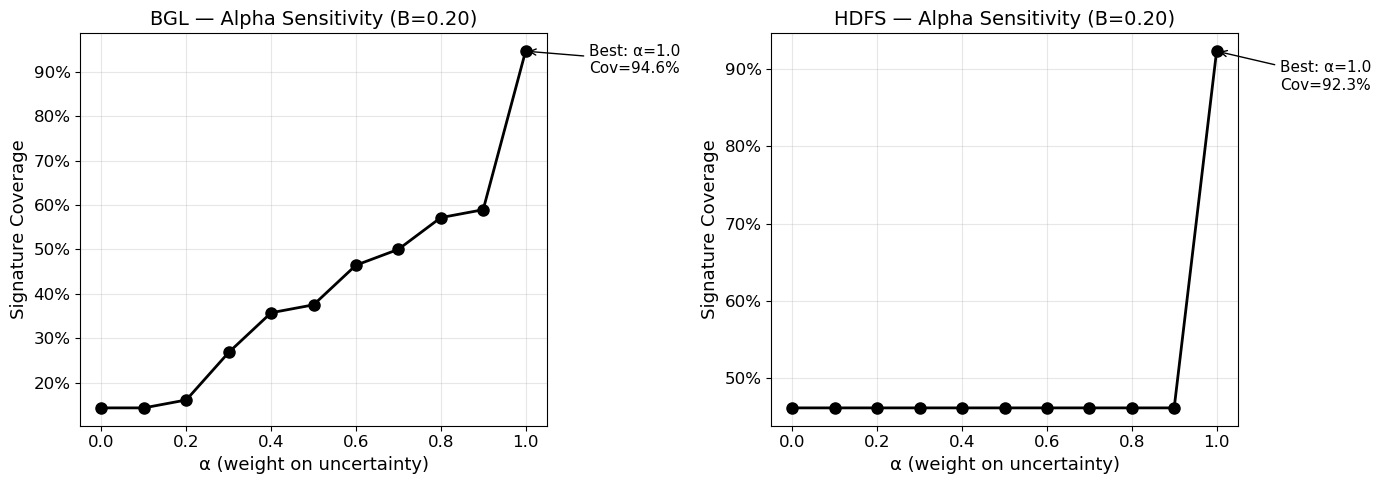

Saved: results/gating_alpha_sensitivity.png


In [20]:
# === Fig 3: Alpha Sensitivity at B=0.20 ===

def alpha_sensitivity(df: pd.DataFrame, budget: float = 0.20) -> pd.DataFrame:
    """Sweep alpha from 0 to 1, compute coverage at fixed budget."""
    K = max(1, int(np.floor(budget * len(df))))
    results = []

    for alpha in ALPHA_LEVELS:
        df_tmp = df.copy()
        df_tmp['s_alpha'] = alpha * df_tmp['u'] + (1 - alpha) * df_tmp['n']
        subset = select_by_score(df_tmp, K, 's_alpha')
        ev = evaluate_subset(subset, df_tmp)
        ev['alpha'] = alpha
        results.append(ev)

    return pd.DataFrame(results)

alpha_bgl = alpha_sensitivity(df_bgl, budget=0.20)
alpha_hdfs = alpha_sensitivity(df_hdfs, budget=0.20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, alpha_df, name in [(axes[0], alpha_bgl, 'BGL'), (axes[1], alpha_hdfs, 'HDFS')]:
    ax.plot(alpha_df['alpha'], alpha_df['coverage'], 'o-',
            color='black', linewidth=2, markersize=8)
    ax.set_xlabel('α (weight on uncertainty)', fontsize=13)
    ax.set_ylabel('Signature Coverage', fontsize=13)
    ax.set_title(f'{name} — Alpha Sensitivity (B=0.20)', fontsize=14)
    ax.set_xlim(-0.05, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

    best_idx = alpha_df['coverage'].idxmax()
    best_row = alpha_df.loc[best_idx]
    ax.annotate(f'Best: α={best_row["alpha"]:.1f}\nCov={best_row["coverage"]:.1%}',
                xy=(best_row['alpha'], best_row['coverage']),
                xytext=(best_row['alpha'] + 0.15, best_row['coverage'] - 0.05),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=11, color='black')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'gating_alpha_sensitivity.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: results/gating_alpha_sensitivity.png")

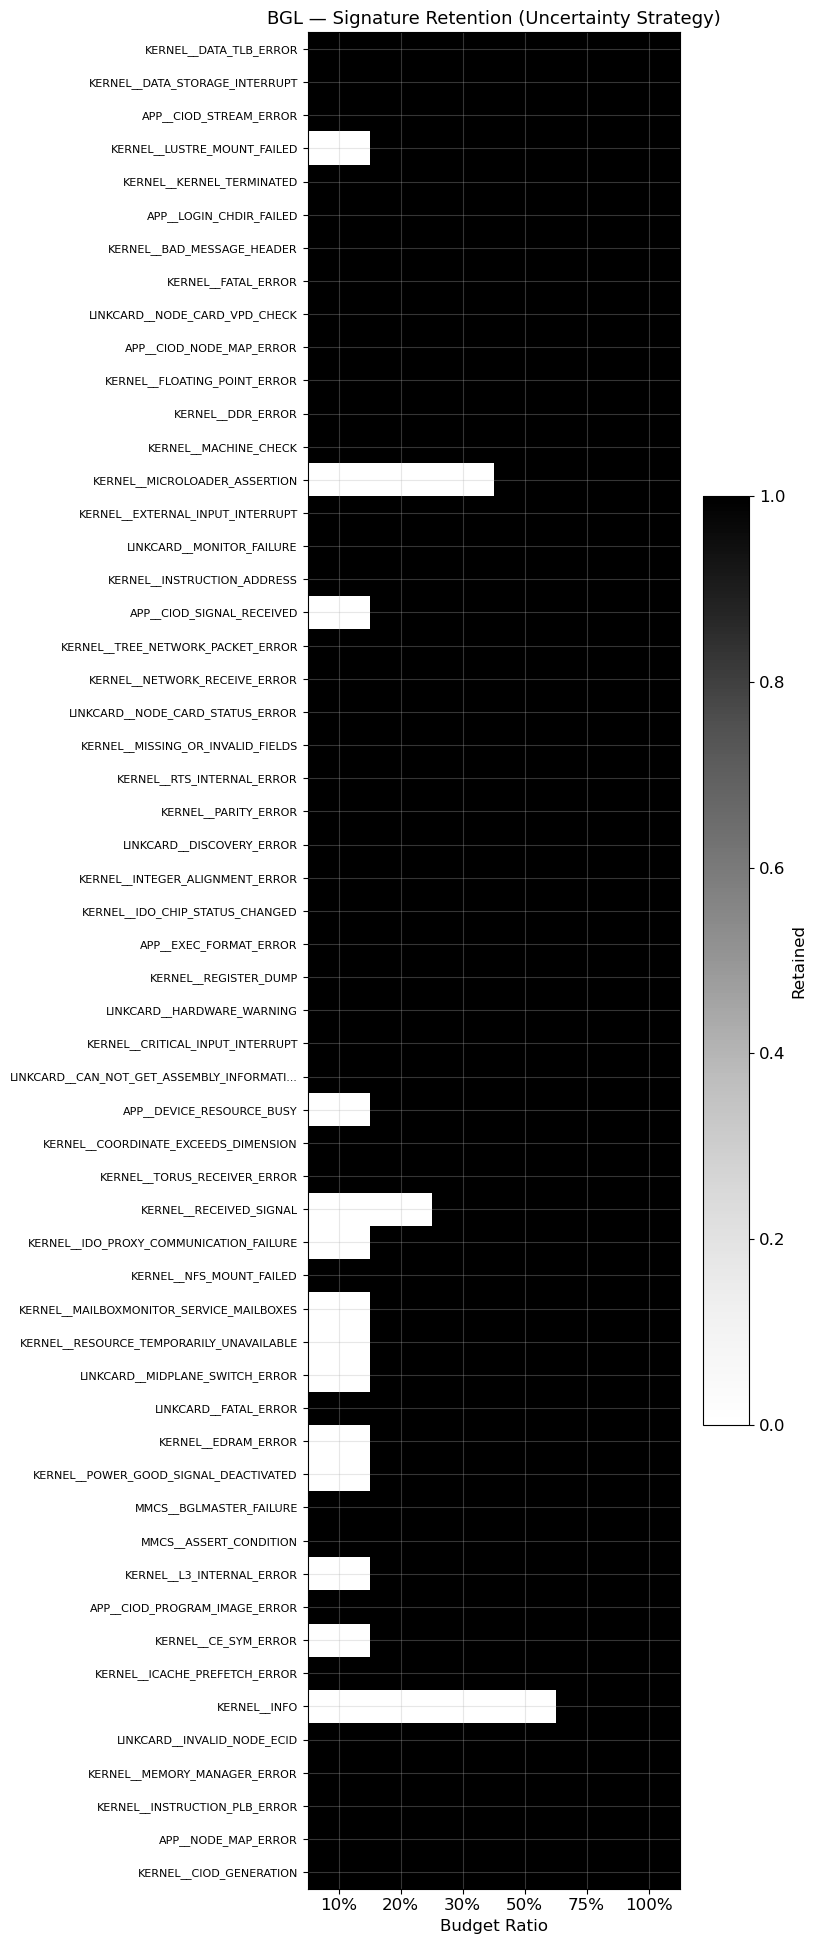

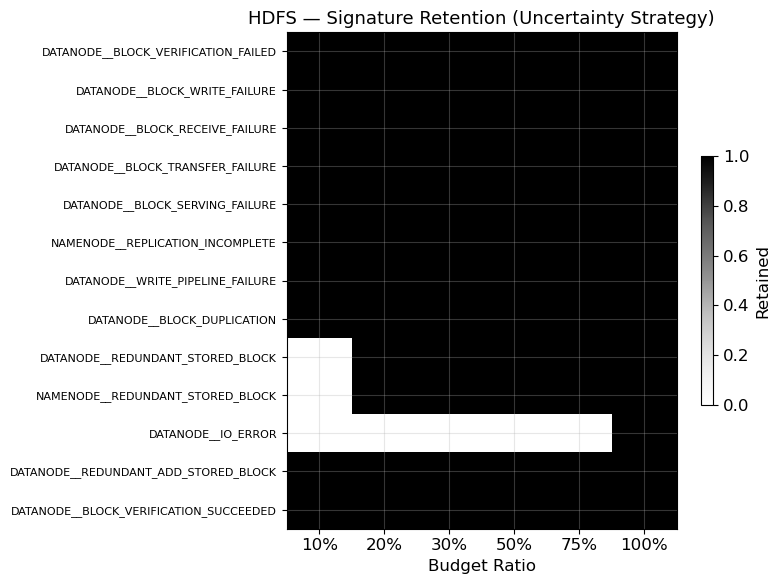

In [21]:
# === Fig 4: Signature Retention Heatmap ===

def signature_retention_heatmap(df: pd.DataFrame, strategy_col: str, dataset_name: str):
    """Show which signatures are retained at each budget level for a specific strategy."""
    all_sigs = df['normalized_signature'].value_counts().index.tolist()

    heatmap_data = np.zeros((len(all_sigs), len(BUDGET_LEVELS)))

    for j, B in enumerate(BUDGET_LEVELS):
        K = max(1, int(np.floor(B * len(df))))
        subset = select_by_score(df, K, strategy_col)
        retained_sigs = set(subset['normalized_signature'].unique())

        for i, sig in enumerate(all_sigs):
            heatmap_data[i, j] = 1.0 if sig in retained_sigs else 0.0

    fig, ax = plt.subplots(figsize=(8, max(6, len(all_sigs) * 0.35)))

    im = ax.imshow(heatmap_data, cmap='Greys', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(BUDGET_LEVELS)))
    ax.set_xticklabels([f'{b:.0%}' for b in BUDGET_LEVELS])
    ax.set_yticks(range(len(all_sigs)))

    short_names = [s[:40] + '...' if len(s) > 40 else s for s in all_sigs]
    ax.set_yticklabels(short_names, fontsize=8)

    ax.set_xlabel('Budget Ratio', fontsize=12)
    ax.set_title(f'{dataset_name} — Signature Retention (Uncertainty Strategy)', fontsize=13)

    plt.colorbar(im, ax=ax, label='Retained', shrink=0.5)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'results' / f'gating_heatmap_{dataset_name}.png', dpi=600, bbox_inches='tight')
    plt.show()

signature_retention_heatmap(df_bgl, 'u', 'BGL')
signature_retention_heatmap(df_hdfs, 'u', 'HDFS')

## 9. Summary & Key Findings

In [22]:
# === Summary Table: B=0.20 across all strategies ===

print("\n" + "="*80)
print("KEY FINDING: Performance at B=0.20 (80% cost savings)")
print("="*80)

for dataset_name in ['BGL', 'HDFS']:
    sim_ds = sim_all[(sim_all['dataset'] == dataset_name) & (sim_all['budget'] == 0.20)]

    print(f"\n--- {dataset_name} ---")
    print(f"{'Strategy':<15} {'Coverage':>10} {'Unique Sigs':>12} {'Token Savings':>14} {'VPR':>8}")
    print("-" * 65)

    for _, row in sim_ds.sort_values('coverage', ascending=False).iterrows():
        cov_str = f"{row['coverage']:.1%}"
        tokens_str = f"{row['token_savings']:.1%}"
        vpr_str = f"{row['vpr']:.2%}"
        print(f"{row['strategy']:<15} {cov_str:>10} {int(row['unique_sigs']):>12} {tokens_str:>14} {vpr_str:>8}")


KEY FINDING: Performance at B=0.20 (80% cost savings)

--- BGL ---
Strategy          Coverage  Unique Sigs  Token Savings      VPR
-----------------------------------------------------------------
Oracle              100.0%           56          80.0%  100.00%
Stratified          100.0%           56          80.0%  100.00%
Uncertainty          94.6%           53          79.7%   99.84%
Random               71.8%           35          80.0%   99.92%
Combined             37.5%           21          80.2%  100.00%
Novelty              14.3%            8          80.2%  100.00%

--- HDFS ---
Strategy          Coverage  Unique Sigs  Token Savings      VPR
-----------------------------------------------------------------
Oracle              100.0%           13          80.1%  100.00%
Stratified          100.0%           13          79.9%  100.00%
Uncertainty          92.3%           12          78.0%  100.00%
Random               69.2%            9          80.2%  100.00%
Novelty           

In [23]:
# === Save all simulation results to JSON ===

save_df = sim_all.copy()
if 'missing_sigs' in save_df.columns:
    save_df['missing_sigs'] = save_df['missing_sigs'].apply(lambda x: list(x) if isinstance(x, set) else x)

output_path = PROJECT_ROOT / 'results' / 'gating_simulation_results.json'
save_df.to_json(output_path, orient='records', indent=2)
print(f"Saved simulation results to {output_path}")

# Also save alpha sensitivity
alpha_results = pd.concat([
    alpha_bgl.assign(dataset='BGL'),
    alpha_hdfs.assign(dataset='HDFS')
], ignore_index=True)

if 'missing_sigs' in alpha_results.columns:
    alpha_results['missing_sigs'] = alpha_results['missing_sigs'].apply(lambda x: list(x) if isinstance(x, set) else x)

alpha_path = PROJECT_ROOT / 'results' / 'gating_alpha_sensitivity_results.json'
alpha_results.to_json(alpha_path, orient='records', indent=2)
print(f"Saved alpha sensitivity results to {alpha_path}")

Saved simulation results to /home/dave/agentic-log-explanations/results/gating_simulation_results.json
Saved alpha sensitivity results to /home/dave/agentic-log-explanations/results/gating_alpha_sensitivity_results.json
